<a href="https://colab.research.google.com/github/Ryanweiii/RFM-Analysis/blob/main/rfm123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Title
## Second Title
- item1
- item2
- item3
**abcde**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df=pd.read_csv('練習檔.csv')
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/04/02,AP1803827,A1067,836.0
1,2018/04/03,AP1808235,A1129,836.0
2,2018/04/04,AP1807305,A1133,836.0
3,2018/04/05,AP1806145,A0464,836.0
4,2018/04/05,AP1803092,A0383,836.0


In [ ]:
import pandas as pd

# 假設你的原始 DataFrame 叫做 df，欄位名稱為：CustomerKey, Date, InvoNo, Amount
# 範例資料結構：
# df = pd.DataFrame({
#     'CustomerKey': ['C001', 'C001', 'C002', 'C002', 'C002'],
#     'Date': ['2026-01-01', '2026-01-10', '2026-01-05', '2026-01-15', '2026-01-20'],
#     'InvoNo': ['INV001', 'INV002', 'INV003', 'INV004', 'INV005'],
#     'Amount': [100, 250, 300, 150, 400]
# })

# 1. 確保「Date」欄位是 datetime 型態，以便後續進行Date計算
df['Date'] = pd.to_datetime(df['Date'])

# 2. 找出整個資料集中的「最大Date」（通常代表資料的基準日或今天）
max_date = df['Date'].max()

# 3. 使用 groupby 進行聚合計算
result_df = (
    df.groupby('CustomerKey')
    .agg(
        F=('InvoNo', 'count'),  # InvoNo計數
        M=('Amount', 'sum'),  # Amount加總
        # 基準最大Date 減去 該客戶的最大Date，並取天數 (dt.days)
        R=('Date', lambda x: (max_date - x.max()).days),
    )
    .reset_index()
)

# 4. 將「CustomerKey」欄位重新命名為「Coustomer」
result_df = result_df.rename(columns={'CustomerKey': 'Coustomer'})

# 調整欄位順序為：Coustomer, F, M, R (非必要，但較符合你的描述順序)
result_df = result_df[['Coustomer', 'F', 'M', 'R']]

print(result_df)

    Coustomer   F            M   R
0       A0350  25  51238.11440   9
1       A0351   6  17890.31200  16
2       A0352  14  46424.03852  14
3       A0353  14  27607.68636  24
4       A0354   6   9973.92064  31
..        ...  ..          ...  ..
727     A1413  23  52738.79456  10
728     A1415  20  53019.49664  17
729     A1416  24  49938.38378   4
730     A1419  22  64257.84520  50
731     A1420  14  25054.18342  85

[732 rows x 4 columns]


In [2]:
import pandas as pd
rfm_data = pd.read_csv('/content/RFM_DATA.csv')
display(rfm_data.head())

,Coustomer,F,M,R
0,A0350,25,51238.11440,9
1,A0351,6,17890.31200,16
2,A0352,14,46424.03852,14
3,A0353,14,27607.68636,24
4,A0354,6,9973.92064,31


In [3]:
from sklearn.preprocessing import MinMaxScaler

# 複製一份資料以進行正規化
nrfm = rfm_data.copy()

# 宣告 MinMaxScaler
scaler = MinMaxScaler()

# 對 F, M, R 欄位進行正規化處理
nrfm[['F', 'M', 'R']] = scaler.fit_transform(nrfm[['F', 'M', 'R']])

# 顯示正規化後的結果
display(nrfm.head())

,Coustomer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


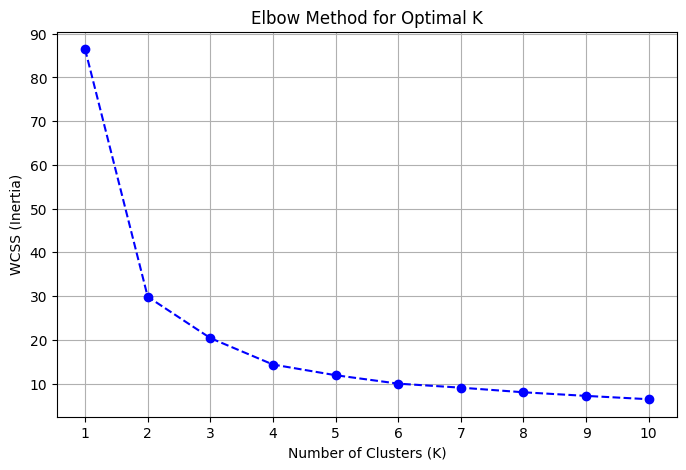

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取特徵欄位 (F, M, R) 進行 K-means 評估
X = nrfm[['F', 'M', 'R']]

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 繪製手肘法圖表 (Elbow Chart)
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [5]:
from sklearn.cluster import KMeans

# 1. 建立 K-means 模型，群數設定為 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 2. 以正規化後的 F, M, R 進行訓練與預測
X = nrfm[['F', 'M', 'R']]
nrfm['Cluster'] = kmeans.fit_predict(X)

# 3. 同步將分群結果紀錄至原始的 rfm_data 方便後續解讀真實數值
rfm_data['Cluster'] = nrfm['Cluster']

# 顯示前 5 筆分群結果
print("--- 正規化資料與分群 (nrfm) ---")
display(nrfm.head())

# 顯示各群的資料筆數與原始數值特徵平均值
print("\n--- 各分群特徵平均值 (原始數值) ---")
cluster_summary = rfm_data.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Avg_F=('F', 'mean'),
    Avg_M=('M', 'mean'),
    Avg_R=('R', 'mean')
).reset_index()
display(cluster_summary)

--- 正規化資料與分群 (nrfm) ---


,Coustomer,F,M,R,Cluster
0,A0350,0.631579,0.376563,0.024523,1
1,A0351,0.131579,0.127866,0.043597,3
2,A0352,0.342105,0.340662,0.038147,2
3,A0353,0.342105,0.200335,0.065395,2
4,A0354,0.131579,0.068827,0.084469,3



--- 各分群特徵平均值 (原始數值) ---


,Cluster,Count,Avg_F,Avg_M,Avg_R
0,0,75,3.640000,8586.611298,183.653333
1,1,131,26.015267,74066.827784,14.786260
2,2,212,18.636792,44033.340535,18.429245
3,3,314,5.570064,13517.754440,45.245223


In [7]:
# 重新讀取原始交易資料
import pandas as pd
df = pd.read_csv('練習檔.csv')

# 將 rfm_data 中的 Coustomer 與 Cluster 提取出來，並與原始 df 合併
df = df.merge(rfm_data[['Coustomer', 'Cluster']], left_on='CustomerKey', right_on='Coustomer', how='left')

# 移除多餘的 Coustomer 欄位以保持資料整潔
df = df.drop(columns=['Coustomer'])

# 顯示合併後的原始資料前 5 筆
display(df.head())

,Date,InvoNo,CustomerKey,Amount,Cluster
0,2018/04/02,AP1803827,A1067,836.0,2
1,2018/04/03,AP1808235,A1129,836.0,2
2,2018/04/04,AP1807305,A1133,836.0,2
3,2018/04/05,AP1806145,A0464,836.0,1
4,2018/04/05,AP1803092,A0383,836.0,3


In [8]:
# 定義 Cluster 與 Group 的對應關係
cluster_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位並進行對應對照
df['Group'] = df['Cluster'].map(cluster_mapping)

# 顯示調整後的前 5 筆資料
display(df.head())

,Date,InvoNo,CustomerKey,Amount,Cluster,Group
0,2018/04/02,AP1803827,A1067,836.0,2,Low
1,2018/04/03,AP1808235,A1129,836.0,2,Low
2,2018/04/04,AP1807305,A1133,836.0,2,Low
3,2018/04/05,AP1806145,A0464,836.0,1,High
4,2018/04/05,AP1803092,A0383,836.0,3,Medium


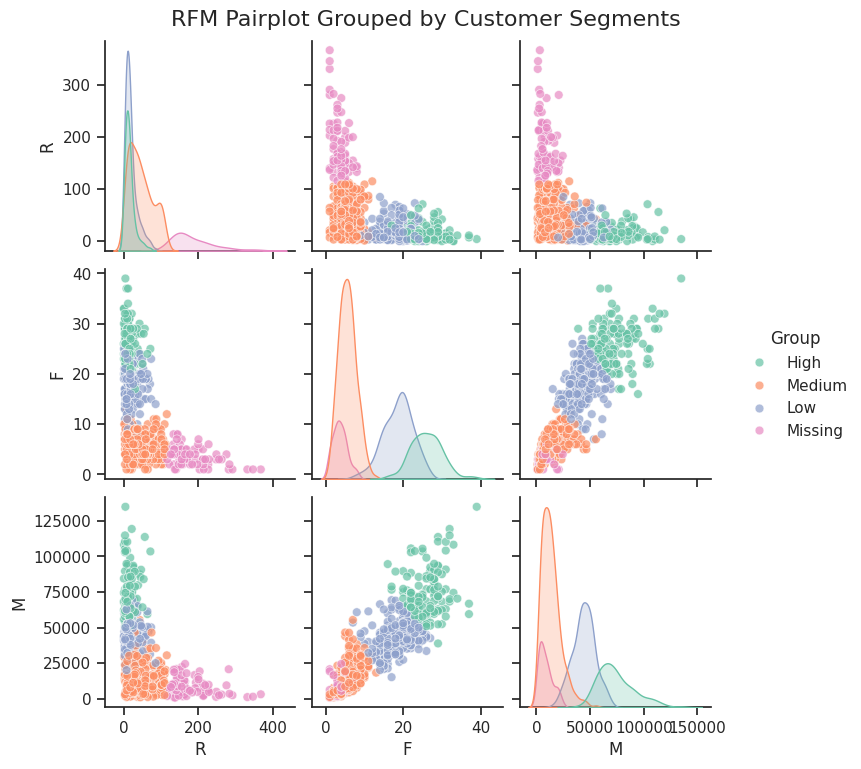

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 將 Group 標籤也對應到顧客層級的 rfm_data 中，以便繪製顧客層級的 RFM 關係圖
rfm_data['Group'] = rfm_data['Cluster'].map(cluster_mapping)

# 設定繪圖風格
sns.set_theme(style="ticks")

# 繪製成對散布圖 (Pairplot)，以 Group 作為分類顏色 (hue)
# 我們設定好群組的順序，讓圖例更易讀
g = sns.pairplot(
    rfm_data[['R', 'F', 'M', 'Group']],
    hue='Group',
    hue_order=['High', 'Medium', 'Low', 'Missing'],
    palette='Set2',
    diag_kind='kde', # 對角線顯示核密度估計圖
    plot_kws={'alpha': 0.7, 's': 40} # 設定散布點的透明度與大小
)

# 設定圖表標題
g.fig.suptitle('RFM Pairplot Grouped by Customer Segments', y=1.02, fontsize=16)
plt.show()

In [10]:
import matplotlib.pyplot as plt
from google.colab import files

# 重新繪製相同的圖表以進行儲存
g = sns.pairplot(
    rfm_data[['R', 'F', 'M', 'Group']],
    hue='Group',
    hue_order=['High', 'Medium', 'Low', 'Missing'],
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40}
)
g.fig.suptitle('RFM Pairplot Grouped by Customer Segments', y=1.02, fontsize=16)

# 將圖表儲存為透明背景的 PNG 格式
output_filename = 'RFM_Pairplot.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', transparent=True)
plt.close()

# 下載圖檔到您的本機電腦
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files

# 將 df 匯出成 CSV 檔案，不保留 pandas 的索引 (index=False)
output_csv = 'RFM_result.csv'
df.to_csv(output_csv, index=False, encoding='utf-8-sig')

# 下載 CSV 檔案到您的本機電腦
files.download(output_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>